/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting GridSearch... (this may take a moment)

--- Ridge Regression Results ---
Best Params: {'model__alpha': 1.0}
R2 Score: 0.6940
MAE: $1,172,754.30
RMSE: $1,586,907.89

--- Random Forest Results ---
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
R2 Score: 0.7210
MAE: $1,079,523.27
RMSE: $1,515,259.75

Generating SHAP Summary Plot...


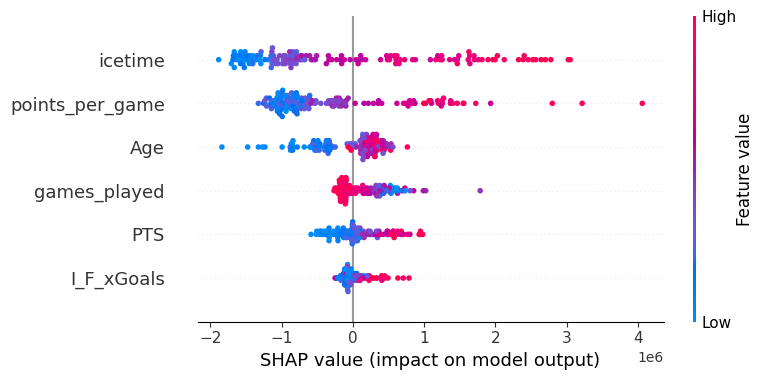

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

df = pd.read_csv('data/cleaned_nhl_data.csv')

df = df[df['games_played'] >= 15]

features = ['PTS', 'Age', 'games_played', 'icetime', 'I_F_xGoals', 'points_per_game']
X = df[features]
y = df['AAV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_ridge = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

print("Starting GridSearch... (this may take a moment)")
grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5, scoring='r2')
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='r2')

grid_ridge.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

def evaluate_model(grid_obj, name):
    preds = grid_obj.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    print(f"\n--- {name} Results ---")
    print(f"Best Params: {grid_obj.best_params_}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    return r2, mae

ridge_r2, ridge_mae = evaluate_model(grid_ridge, "Ridge Regression")
rf_r2, rf_mae = evaluate_model(grid_rf, "Random Forest")

print("\nGenerating SHAP Summary Plot...")
best_rf_model = grid_rf.best_estimator_.named_steps['model']
preprocessor = Pipeline(grid_rf.best_estimator_.steps[:-1])
X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=features)

In [2]:
all_preds = grid_rf.predict(X)

results = df[['name', 'AAV']].copy()
results['Predicted_AAV'] = all_preds
results['Difference'] = results['Predicted_AAV'] - results['AAV']

underpaid = results.sort_values(by='Difference', ascending=False).head(10)

overpaid = results.sort_values(by='Difference', ascending=True).head(10)

print("--- Top 10 Undervalued Players (Model Value > Actual Pay) ---")
print(underpaid[['name', 'AAV', 'Predicted_AAV', 'Difference']].head(10))

print("\n--- Top 10 Overvalued Players (Actual Pay > Model Value) ---")
print(overpaid[['name', 'AAV', 'Predicted_AAV', 'Difference']].head(10))

--- Top 10 Undervalued Players (Model Value > Actual Pay) ---
                     name        AAV  Predicted_AAV   Difference
371           Kyle Connor  7142857.0   1.078762e+07  3644767.995
56        Simon Edvinsson   894167.0   4.442640e+06  3548473.100
81            Jake Walman  3400000.0   6.845045e+06  3445045.000
284            Ryan Suter   775000.0   3.960250e+06  3185250.000
131        Dmitry Kulikov  1150000.0   4.192676e+06  3042675.740
581      Marcus Johansson   800000.0   3.548288e+06  2748287.500
45        Jackson LaCombe   925000.0   3.553537e+06  2628536.805
390  Oliver Ekman-Larsson  3500000.0   5.955533e+06  2455533.235
208        Josh Morrissey  6250000.0   8.516458e+06  2266458.330
700        William Eklund   863333.0   2.718625e+06  1855291.775

--- Top 10 Overvalued Players (Actual Pay > Model Value) ---
                  name         AAV  Predicted_AAV   Difference
327   Elias Pettersson  11600000.0    6366500.820 -5233499.180
136    Hampus Lindholm   6500000.0 

In [3]:
def check_player_value(player_name):
    player_data = results[results['name'].str.contains(player_name, case=False, na=False)]
    
    if player_data.empty:
        return f"Player '{player_name}' not found in the dataset."
    
    row = player_data.iloc[0]
    status = "UNDERVALUED" if row['Difference'] > 0 else "OVERVALUED"
    
    print(f"--- Analysis for {row['name']} ---")
    print(f"Actual AAV:    ${row['AAV']:,.0f}")
    print(f"Predicted AAV: ${row['Predicted_AAV']:,.0f}")
    print(f"Difference:    ${row['Difference']:,.0f} ({status})")

check_player_value("Leon Draisaitl")
print("\n")
check_player_value("Kirill Kaprizov")

--- Analysis for Leon Draisaitl ---
Actual AAV:    $14,000,000
Predicted AAV: $13,097,000
Difference:    $-903,000 (OVERVALUED)


--- Analysis for Kirill Kaprizov ---
Actual AAV:    $9,000,000
Predicted AAV: $8,996,631
Difference:    $-3,369 (OVERVALUED)


In [4]:
import joblib

joblib.dump(grid_rf.best_estimator_, 'src/rf_model.pkl')

results = df[['name', 'AAV', 'PTS', 'I_F_xGoals', 'Age']].copy()
results['Predicted_AAV'] = all_preds
results['Difference'] = results['Predicted_AAV'] - results['AAV']

results.to_csv('data/valuation_results.csv', index=False)

print("Model and results exported successfully!")

Model and results exported successfully!


Unsupervised Model

--- Cluster Profiles (Averages) ---
                  AAV        PTS       icetime        Age  points_per_game
Cluster                                                                   
0        4.048969e+06  24.990000  76610.120000  31.730000         0.375337
1        6.786290e+06  64.905797  88265.992754  27.565217         0.861269
2        1.411259e+06   6.395604  25284.060440  26.609890         0.209685
3        2.881737e+06  22.912568  67235.245902  24.535519         0.347938


/tmp/ipykernel_505/3054652500.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Cluster'] = kmeans.fit_predict(X_scaled)


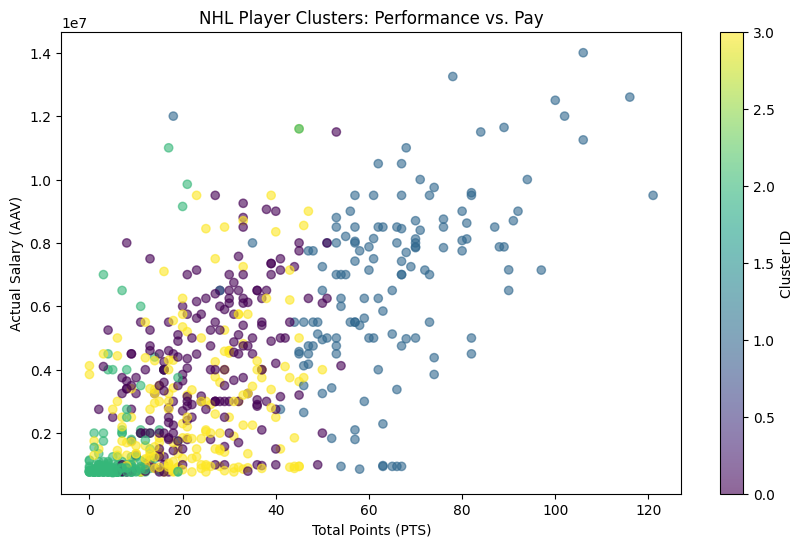

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

X_scaled = preprocessor.transform(X)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('Cluster')[['AAV', 'PTS', 'icetime', 'Age', 'points_per_game']].mean()
print("--- Cluster Profiles (Averages) ---")
print(cluster_summary)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['PTS'], df['AAV'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.title("NHL Player Clusters: Performance vs. Pay")
plt.xlabel("Total Points (PTS)")
plt.ylabel("Actual Salary (AAV)")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

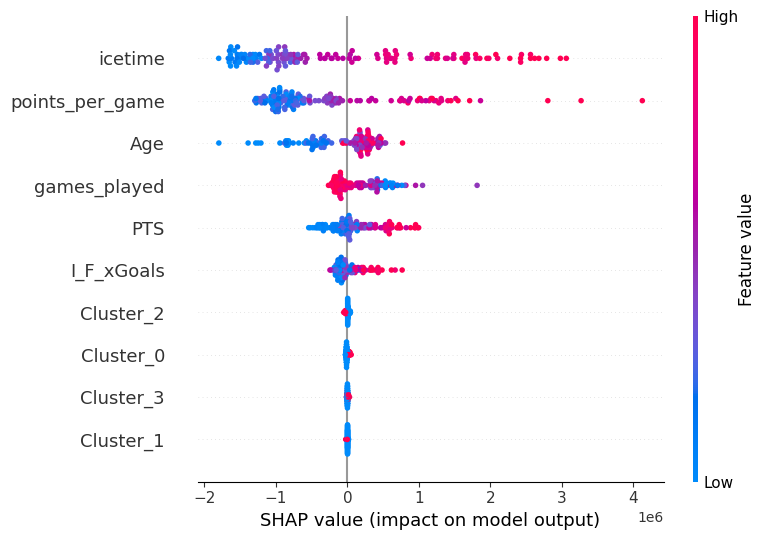

In [7]:
features = ['PTS', 'Age', 'games_played', 'icetime', 'I_F_xGoals', 'points_per_game', 'Cluster']
X = df[features]
y = df['AAV']

X = pd.get_dummies(X, columns=['Cluster'], prefix='Cluster')

feature_names_final = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
grid_rf.fit(X_train, y_train)

best_rf_model = grid_rf.best_estimator_.named_steps['model']
preprocessor = Pipeline(grid_rf.best_estimator_.steps[:-1])
X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_final)

In [ ]:
rf_r2 = grid_rf.score(X_test, y_test)
print(f"New Random Forest R2 Score: {rf_r2:.4f}")

from sklearn.metrics import mean_absolute_error
y_pred = grid_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred)
print(f"New Mean Absolute Error: ${rf_mae:,.2f}")

New Random Forest R2 Score: 0.7237
New Mean Absolute Error: $1,079,844.58
